In [1]:
!pip install pandas openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
print(os.listdir())

['All Matches.csv', 'README.md', 'All NCAA Player Rankings.csv', 'BSANStat.ipynb', '.git', 'All NFL Scouting Combine Results.csv']


In [3]:
import pandas as pd

df1 = pd.read_csv("All Matches.csv", encoding="latin1")
df2 = pd.read_csv("All NCAA Player Rankings.csv", encoding="latin1")
df3 = pd.read_csv("All NFL Scouting Combine Results.csv", encoding="latin1")

In [4]:
df1.head()

,Season,Name,Position,Team,Conference,AveragePPA All,AveragePPA Pass,AveragePPA Rush,AveragePPA FirstDown,AveragePPA SecondDown,...,Arm (inches),Wingspan (inches),40-Yard Dash (seconds),Vertical (inches),Bench (reps),Broad Jump (inches),3-Cone (seconds),Shuttle (seconds),Overall Pick,Combine Participation
0,2025,Haynes King,QB,Georgia Tech,ACC,0.321,0.354,0.323,0.160,0.308,...,31.875,86.54,4.46,33.50,11,116.00,6.89,4.17,300,1
1,2025,Joe Fagnano,QB,UConn,Ind,0.476,0.476,0.474,0.237,0.531,...,31.375,80.14,4.83,35.00,17,118.00,6.17,4.35,300,1
2,2025,Caullin Lacy,WR,Louisville,ACC,0.163,0.232,-0.196,-0.141,0.429,...,29.375,70.67,4.55,33.50,29,116.00,6.35,4.56,300,1
3,2025,Carson Beck,QB,Miami,ACC,0.306,0.351,0.048,0.148,0.273,...,30.625,75.00,4.55,68.29,14,147.56,9.47,6.22,65,1
4,2025,Taylen Green,QB,Arkansas,SEC,0.415,0.344,0.680,0.167,0.524,...,34.750,79.41,4.36,43.50,18,134.00,6.10,5.42,182,1


In [5]:
print(df1.shape)
print(df2.shape)
print(df3.shape)

(326, 36)
(12409, 23)
(1277, 18)


In [6]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['Season', 'Name', 'Position', 'Team', 'Conference', 'AveragePPA All',
       'AveragePPA Pass', 'AveragePPA Rush', 'AveragePPA FirstDown',
       'AveragePPA SecondDown', 'AveragePPA ThirdDown',
       'AveragePPA StandardDowns', 'AveragePPA PassingDowns', 'TotalPPA All',
       'TotalPPA Pass', 'TotalPPA Rush', 'TotalPPA FirstDown',
       'TotalPPA SecondDown', 'TotalPPA ThirdDown', 'TotalPPA StandardDowns',
       'TotalPPA PassingDowns', 'index_combine', 'Season_combine',
       'Height (inches)', 'Weight(lbs)', 'Hand (inches)', 'Arm (inches)',
       'Wingspan (inches)', '40-Yard Dash (seconds)', 'Vertical (inches)',
       'Bench (reps)', 'Broad Jump (inches)', '3-Cone (seconds)',
       'Shuttle (seconds)', 'Overall Pick', 'Combine Participation'],
      dtype='str')
Index(['Season', 'Name', 'Position', 'Team', 'Conference', 'AveragePPA All',
       'AveragePPA Pass', 'AveragePPA Rush', 'AveragePPA FirstDown',
       'AveragePPA SecondDown', 'AveragePPA ThirdDown',
      

In [7]:
summary_stats = df1.describe().T
summary_stats["median"] = df1.median(numeric_only=True)

summary_stats

,count,mean,std,min,25%,50%,75%,max,median
Season,326.0,2024.046012,0.804430,2023.000,2023.00000,2024.0000,2025.00000,2025.000,2024.0000
AveragePPA All,326.0,0.593871,0.398821,-1.108,0.30375,0.5360,0.87275,2.411,0.5360
AveragePPA Pass,326.0,0.663187,0.403747,-1.108,0.40125,0.6280,0.92525,2.411,0.6280
AveragePPA Rush,326.0,0.203187,0.745030,-3.628,-0.07175,0.2205,0.47725,3.519,0.2205
AveragePPA FirstDown,326.0,0.416558,0.381328,-1.108,0.14625,0.3440,0.63325,2.097,0.3440
AveragePPA SecondDown,326.0,0.576368,0.457011,-0.697,0.25625,0.5210,0.88600,2.411,0.5210
AveragePPA ThirdDown,326.0,0.957939,0.586473,-1.500,0.59925,0.8650,1.32500,2.753,0.8650
AveragePPA StandardDowns,326.0,0.489356,0.365180,-1.108,0.23675,0.4340,0.73100,1.755,0.4340
AveragePPA PassingDowns,326.0,0.796322,0.552773,-1.267,0.40775,0.7175,1.14425,2.624,0.7175
TotalPPA All,326.0,61.732258,53.521327,-7.402,26.56750,48.5890,75.85425,300.687,48.5890


In [8]:
df1["Drafted"] = df1["Overall Pick"].apply(lambda x: "Drafted" if x != 300 else "Undrafted")

In [9]:
df1.groupby("Drafted").mean(numeric_only=True)

,Season,AveragePPA All,AveragePPA Pass,AveragePPA Rush,AveragePPA FirstDown,AveragePPA SecondDown,AveragePPA ThirdDown,AveragePPA StandardDowns,AveragePPA PassingDowns,TotalPPA All,...,Arm (inches),Wingspan (inches),40-Yard Dash (seconds),Vertical (inches),Bench (reps),Broad Jump (inches),3-Cone (seconds),Shuttle (seconds),Overall Pick,Combine Participation
Drafted,,,,,,,,,,,,,,,,,,,,,
Drafted,2024.00000,0.616717,0.684165,0.236861,0.432378,0.588330,0.98650,0.512661,0.816809,65.848904,...,31.33750,76.633609,4.633826,36.489304,20.873913,123.190739,7.065478,4.430565,123.934783,0.786957
Undrafted,2024.15625,0.539135,0.612927,0.122510,0.378656,0.547708,0.88951,0.433521,0.747240,51.869458,...,31.36849,76.613646,4.592500,35.909167,20.562500,121.961562,7.111563,4.351042,300.000000,0.802083


In [10]:
df1.groupby("Drafted").median(numeric_only=True)

,Season,AveragePPA All,AveragePPA Pass,AveragePPA Rush,AveragePPA FirstDown,AveragePPA SecondDown,AveragePPA ThirdDown,AveragePPA StandardDowns,AveragePPA PassingDowns,TotalPPA All,...,Arm (inches),Wingspan (inches),40-Yard Dash (seconds),Vertical (inches),Bench (reps),Broad Jump (inches),3-Cone (seconds),Shuttle (seconds),Overall Pick,Combine Participation
Drafted,,,,,,,,,,,,,,,,,,,,,
Drafted,2024.0,0.563,0.6425,0.2405,0.360,0.5265,0.891,0.4525,0.7525,51.5255,...,31.375,76.5000,4.48,36.00,21.0,122.95,6.975,4.30,122.5,1.0
Undrafted,2024.0,0.480,0.5705,0.1955,0.285,0.4495,0.834,0.3635,0.6280,36.6415,...,31.500,76.6875,4.57,35.25,19.5,122.00,7.005,4.31,300.0,1.0


In [11]:
df1.groupby("Drafted").quantile([0.25, 0.50, 0.75], numeric_only=True)

Season  AveragePPA All  AveragePPA Pass  AveragePPA Rush  \
Drafted                                                                    
Drafted   0.25  2023.0         0.31925          0.42200         -0.04975   
          0.50  2024.0         0.56300          0.64250          0.24050   
          0.75  2025.0         0.89675          0.92850          0.50725   
Undrafted 0.25  2024.0         0.26300          0.37475         -0.09950   
          0.50  2024.0         0.48000          0.57050          0.19550   
          0.75  2025.0         0.80725          0.91075          0.41625   

                AveragePPA FirstDown  AveragePPA SecondDown  \
Drafted                                                       
Drafted   0.25               0.15100                0.28400   
          0.50               0.36000                0.52650   
          0.75               0.62900                0.90000   
Undrafted 0.25               0.12500                0.22375   
          0.50               0.28500                0.44950   
          0.75               0.64425                0.86525   

                AveragePPA ThirdDown  AveragePPA StandardDowns  \
Drafted                                                          
Drafted   0.25               0.61225                   0.25800   
          0.50               0.89100                   0.45250   
          0.75               1.35875                   0.75250   
Undrafted 0.25               0.52675                   0.19225   
          0.50               0.83400                   0.36350   
          0.75               1.27475                   0.68950   

                AveragePPA PassingDowns  TotalPPA All  ...  Arm (inches)  \
Drafted                                                ...                 
Drafted   0.25                  0.42100      31.24325  ...      30.40625   
          0.50                  0.75250      51.52550  ...      31.37500   
          0.75                  1.14500      77.92650  ...      32.12500   
Undrafted 0.25                  0.39075      21.22150  ...      30.46875   
          0.50                  0.62800      36.64150  ...      31.50000   
          0.75                  1.13200      61.75825  ...      32.12500   

                Wingspan (inches)  40-Yard Dash (seconds)  Vertical (inches)  \
Drafted                                                                        
Drafted   0.25           74.28125                    4.40              34.00   
          0.50           76.50000                    4.48              36.00   
          0.75           78.62500                    4.62              38.50   
Undrafted 0.25           73.35375                    4.45              32.50   
          0.50           76.68750                    4.57              35.25   
          0.75           79.02000                    4.65              38.00   

                Bench (reps)  Broad Jump (inches)  3-Cone (seconds)  \
Drafted                                                               
Drafted   0.25          15.0               119.00            6.8100   
          0.50          21.0               122.95            6.9750   
          0.75          26.0               128.00            7.3125   
Undrafted 0.25          15.0               116.75            6.7700   
          0.50          19.5               122.00            7.0050   
          0.75          25.0               125.00            7.2900   

                Shuttle (seconds)  Overall Pick  Combine Participation  
Drafted                                                                 
Drafted   0.25             4.1400         59.25                    1.0  
          0.50             4.3000        122.50                    1.0  
          0.75             4.5000        184.75                    1.0  
Undrafted 0.25             4.1475        300.00                    1.0  
          0.50             4.3100        300.00                    1.0  
          0.75             4.4450        30

In [12]:
!pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


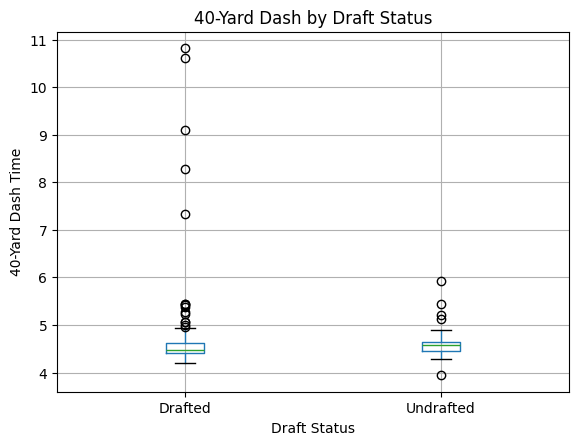

In [13]:
import matplotlib.pyplot as plt

df1.boxplot(column="40-Yard Dash (seconds)", by="Drafted")

plt.title("40-Yard Dash by Draft Status")
plt.suptitle("")
plt.xlabel("Draft Status")
plt.ylabel("40-Yard Dash Time")
plt.show()

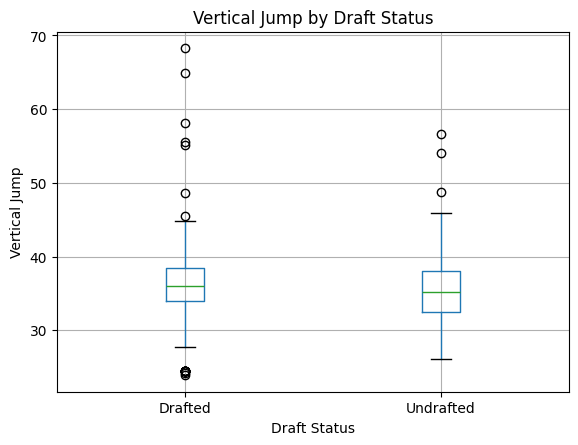

In [14]:
df1.boxplot(column="Vertical (inches)", by="Drafted")

plt.title("Vertical Jump by Draft Status")
plt.suptitle("")
plt.xlabel("Draft Status")
plt.ylabel("Vertical Jump")
plt.show()

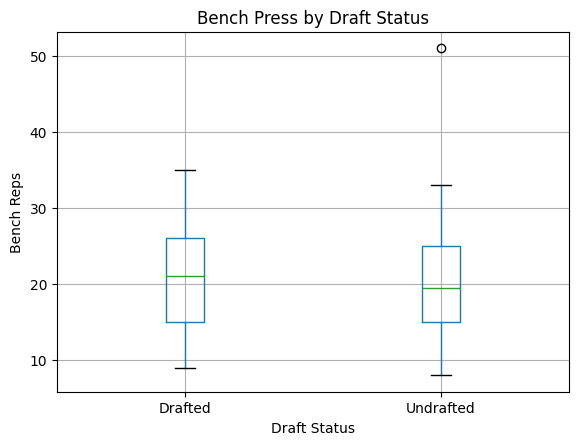

In [15]:
df1.boxplot(column="Bench (reps)", by="Drafted")

plt.title("Bench Press by Draft Status")
plt.suptitle("")
plt.xlabel("Draft Status")
plt.ylabel("Bench Reps")
plt.show()

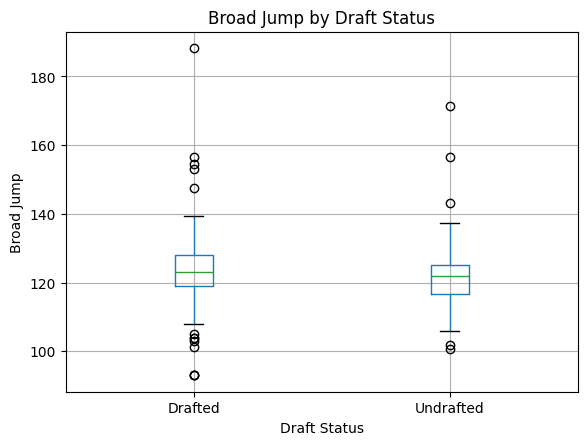

In [16]:
df1.boxplot(column="Broad Jump (inches)", by="Drafted")

plt.title("Broad Jump by Draft Status")
plt.suptitle("")
plt.xlabel("Draft Status")
plt.ylabel("Broad Jump")
plt.show()

In [17]:
!pip install scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [18]:
from scipy.stats import zscore

combine_cols = [
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)"
]

# Create Z-score columns
for col in combine_cols:
    df1[col + "_z"] = zscore(df1[col], nan_policy='omit')

In [19]:
df1["40-Yard Dash (seconds)_z"] *= -1
df1["3-Cone (seconds)_z"] *= -1
df1["Shuttle (seconds)_z"] *= -1

In [20]:
z_cols = [col + "_z" for col in combine_cols]

df1["Above_Average_Events"] = (df1[z_cols] > 0).sum(axis=1)

In [21]:
df1[["Name", "Position", "Above_Average_Events"]].head()

,Name,Position,Above_Average_Events
0,Haynes King,QB,3
1,Joe Fagnano,QB,2
2,Caullin Lacy,WR,3
3,Carson Beck,QB,3
4,Taylen Green,QB,4


In [22]:
df1.groupby("Drafted")["Above_Average_Events"].mean()

Drafted
Drafted      3.569565
Undrafted    3.218750
Name: Above_Average_Events, dtype: float64

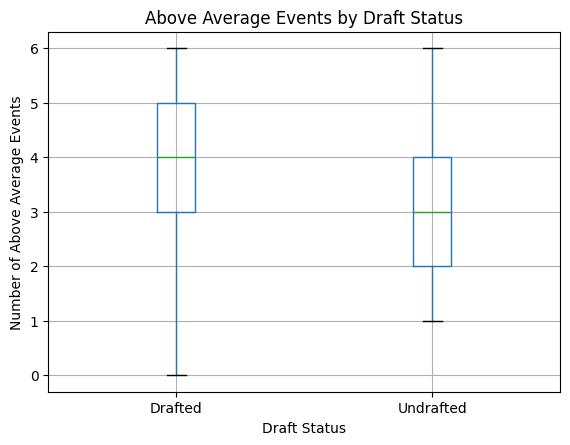

In [23]:
df1.boxplot(column="Above_Average_Events", by="Drafted")

plt.title("Above Average Events by Draft Status")
plt.suptitle("")
plt.xlabel("Draft Status")
plt.ylabel("Number of Above Average Events")
plt.show()

In [24]:
df1["40_Rank_Pos"] = df1.groupby("Position")["40-Yard Dash (seconds)"] \
    .rank(method="min", ascending=True)

In [25]:
df1["Vertical_Rank_Pos"] = df1.groupby("Position")["Vertical (inches)"] \
    .rank(method="min", ascending=False)

In [26]:
df1["Bench_Rank_Pos"] = df1.groupby("Position")["Bench (reps)"] \
    .rank(method="min", ascending=False)

In [27]:
df1["Broad_Rank_Pos"] = df1.groupby("Position")["Broad Jump (inches)"] \
    .rank(method="min", ascending=False)

In [28]:
df1["Cone_Rank_Pos"] = df1.groupby("Position")["3-Cone (seconds)"] \
    .rank(method="min", ascending=True)

In [29]:
df1["Shuttle_Rank_Pos"] = df1.groupby("Position")["Shuttle (seconds)"] \
    .rank(method="min", ascending=True)

In [30]:
df1[[
    "Name",
    "Position",
    "40_Rank_Pos",
    "Vertical_Rank_Pos",
    "Bench_Rank_Pos"
]].head(20)

,Name,Position,40_Rank_Pos,Vertical_Rank_Pos,Bench_Rank_Pos
0,Haynes King,QB,13.0,21.0,38.0
1,Joe Fagnano,QB,33.0,18.0,18.0
2,Caullin Lacy,WR,112.0,114.0,6.0
3,Carson Beck,QB,14.0,1.0,30.0
4,Taylen Green,QB,11.0,9.0,14.0
5,Chris Hilton Jr.,WR,44.0,106.0,40.0
6,Behren Morton,QB,11.0,20.0,38.0
7,Eli Stowers,TE,7.0,2.0,52.0
8,Matthew Hibner,TE,10.0,13.0,17.0
9,Noah Whittington,RB,56.0,2.0,26.0


In [31]:
df1["40_Percentile_Pos"] = df1.groupby("Position")["40-Yard Dash (seconds)"] \
    .rank(pct=True, ascending=False)

In [32]:
wr = df1[df1["Position"] == "WR"]

wr.groupby("Drafted")["40-Yard Dash (seconds)"].mean()

Drafted
Drafted      4.441753
Undrafted    4.509750
Name: 40-Yard Dash (seconds), dtype: float64

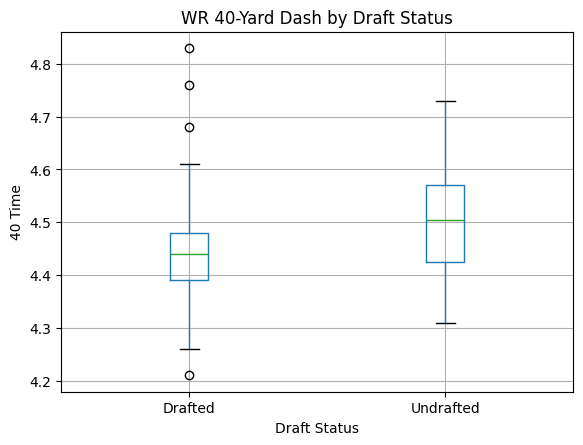

In [33]:
wr.boxplot(column="40-Yard Dash (seconds)", by="Drafted")

plt.title("WR 40-Yard Dash by Draft Status")
plt.suptitle("")
plt.xlabel("Draft Status")
plt.ylabel("40 Time")
plt.show()

In [34]:
metrics = [
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)"
]

positions = df1["Position"].unique()

for pos in positions:
    
    subset = df1[df1["Position"] == pos]
    
    print(f"\n===== {pos} =====")
    
    for metric in metrics:
        
        drafted_mean = subset[subset["Drafted"] == "Drafted"][metric].mean()
        undrafted_mean = subset[subset["Drafted"] == "Undrafted"][metric].mean()
        
        print(f"{metric}")
        print(f"Drafted Avg: {drafted_mean:.2f}")
        print(f"Undrafted Avg: {undrafted_mean:.2f}")
        print()


===== QB =====
40-Yard Dash (seconds)
Drafted Avg: 5.32
Undrafted Avg: 4.72

Vertical (inches)
Drafted Avg: 37.26
Undrafted Avg: 37.20

Bench (reps)
Drafted Avg: 17.55
Undrafted Avg: 14.50

Broad Jump (inches)
Drafted Avg: 123.95
Undrafted Avg: 124.35

3-Cone (seconds)
Drafted Avg: 7.41
Undrafted Avg: 7.58

Shuttle (seconds)
Drafted Avg: 4.71
Undrafted Avg: 4.52


===== WR =====
40-Yard Dash (seconds)
Drafted Avg: 4.44
Undrafted Avg: 4.51

Vertical (inches)
Drafted Avg: 37.12
Undrafted Avg: 36.37

Bench (reps)
Drafted Avg: 18.70
Undrafted Avg: 18.75

Broad Jump (inches)
Drafted Avg: 125.29
Undrafted Avg: 123.68

3-Cone (seconds)
Drafted Avg: 6.91
Undrafted Avg: 6.90

Shuttle (seconds)
Drafted Avg: 4.23
Undrafted Avg: 4.33


===== TE =====
40-Yard Dash (seconds)
Drafted Avg: 4.74
Undrafted Avg: 4.74

Vertical (inches)
Drafted Avg: 35.06
Undrafted Avg: 34.15

Bench (reps)
Drafted Avg: 25.30
Undrafted Avg: 26.00

Broad Jump (inches)
Drafted Avg: 119.70
Undrafted Avg: 117.42

3-Cone (seco

In [35]:
from IPython.display import display

metrics = [
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)"
]

positions = sorted(df1["Position"].dropna().unique())

results = []

for pos in positions:
    
    subset = df1[df1["Position"] == pos]
    
    for metric in metrics:
        
        corr = subset[metric].corr(subset["Overall Pick"])
        
        results.append({
            "Position": pos,
            "Metric": metric,
            "Correlation with Overall Pick": round(corr, 3)
        })

results_df = pd.DataFrame(results)

display(results_df)

,Position,Metric,Correlation with Overall Pick
0,QB,40-Yard Dash (seconds),-0.320
1,QB,Vertical (inches),-0.135
2,QB,Bench (reps),-0.199
3,QB,Broad Jump (inches),-0.148
4,QB,3-Cone (seconds),-0.002
5,QB,Shuttle (seconds),-0.040
6,RB,40-Yard Dash (seconds),0.233
7,RB,Vertical (inches),-0.141
8,RB,Bench (reps),0.053
9,RB,Broad Jump (inches),-0.125


In [36]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


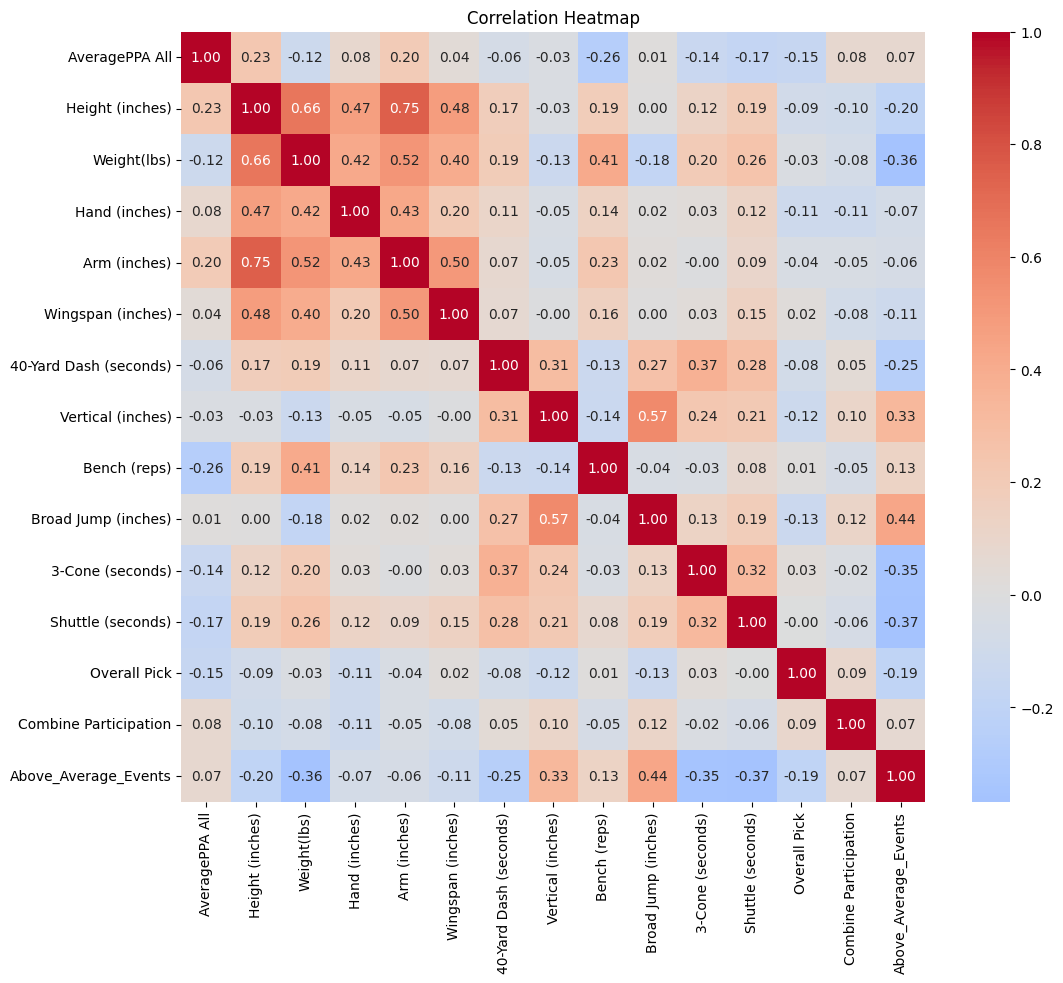

In [37]:
selected_cols = [
    "AveragePPA All",
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Arm (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Overall Pick",
    "Combine Participation",
    "Above_Average_Events"
]

corr_matrix = df1[selected_cols].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [38]:
metrics = [
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Above_Average_Events",
    "AveragePPA All"
]

positions = sorted(df1["Position"].dropna().unique())

results = []

for pos in positions:
    
    subset = df1[df1["Position"] == pos]
    
    row = {"Position": pos}
    
    for metric in metrics:
        
        corr = subset[metric].corr(subset["Overall Pick"])
        row[metric] = corr
        
    results.append(row)

position_matrix = pd.DataFrame(results)

position_matrix

,Position,40-Yard Dash (seconds),Vertical (inches),Bench (reps),Broad Jump (inches),3-Cone (seconds),Shuttle (seconds),Above_Average_Events,AveragePPA All
0,QB,-0.320418,-0.134573,-0.198549,-0.147745,-0.002047,-0.039978,-0.019673,-0.357640
1,RB,0.232648,-0.140703,0.052916,-0.124502,0.117729,0.018501,-0.273521,-0.254091
2,TE,0.007092,-0.125053,-0.015217,-0.193589,0.117111,-0.165166,-0.254811,-0.185159
3,WR,0.274323,-0.119687,-0.015102,-0.088587,-0.009999,0.165702,-0.235704,-0.099181


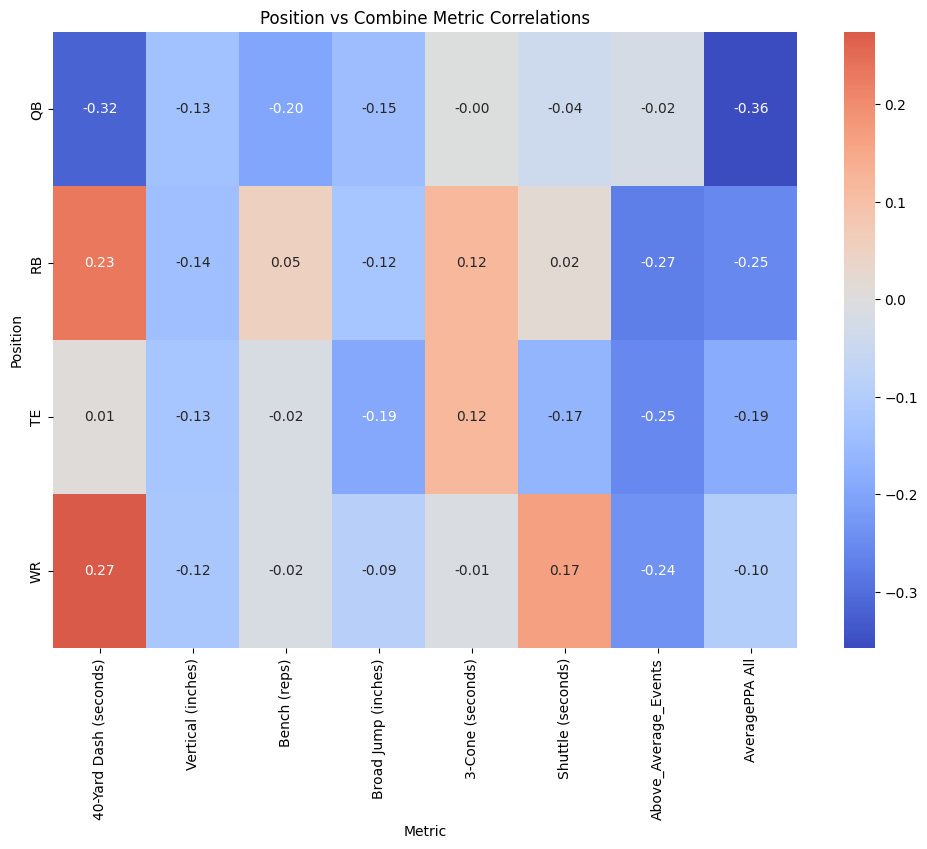

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = position_matrix.set_index("Position")

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Position vs Combine Metric Correlations")
plt.xlabel("Metric")
plt.ylabel("Position")

plt.show()

In [40]:
!pip install --upgrade scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

fa_vars = df1[[
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Arm (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)"
]].dropna()

scaled_vars = StandardScaler().fit_transform(fa_vars)

pca = PCA(n_components=4)
pca.fit(scaled_vars)

loadings = pd.DataFrame(
    pca.components_.T,
    index=fa_vars.columns,
    columns=["Factor1", "Factor2", "Factor3", "Factor4"]
)

loadings

,Factor1,Factor2,Factor3,Factor4
Height (inches),0.483807,-0.038340,-0.123187,-0.171393
Weight(lbs),0.456372,-0.089074,0.264785,0.082491
Hand (inches),0.337555,-0.046640,-0.115140,-0.180993
Arm (inches),0.445954,-0.100451,-0.292148,-0.106303
Wingspan (inches),0.350486,-0.047831,-0.220278,-0.036066
40-Yard Dash (seconds),0.150308,0.437201,0.193696,-0.294237
Vertical (inches),-0.008738,0.525744,-0.325644,0.157012
Bench (reps),0.211327,-0.184924,0.114569,0.820226
Broad Jump (inches),0.006691,0.476224,-0.473113,0.272468
3-Cone (seconds),0.125306,0.377066,0.522457,-0.074177


In [46]:
explained = pd.DataFrame({
    "Factor": ["Factor1", "Factor2", "Factor3", "Factor4"],
    "Explained Variance": pca.explained_variance_ratio_
})

explained

,Factor,Explained Variance
0,Factor1,0.294138
1,Factor2,0.196253
2,Factor3,0.103245
3,Factor4,0.087973


In [47]:
reg_df = df1[[
    "Overall Pick",
    "AveragePPA All",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Position"
]].dropna()

In [48]:
reg_df = pd.get_dummies(
    reg_df,
    columns=["Position"],
    drop_first=True
)

In [55]:
import pandas as pd
import statsmodels.api as sm

In [61]:
drafted_df = df1[df1["Overall Pick"] != 300]

ols_df = drafted_df[[
    "Overall Pick",
    "AveragePPA All",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Position"
]].dropna()

# Include ALL position dummies
ols_df = pd.get_dummies(
    ols_df,
    columns=["Position"],
    drop_first=False
)

ols_df = ols_df.astype(float)

X = ols_df.drop(columns=["Overall Pick"])
y = ols_df["Overall Pick"]

# No constant because all positions are included
ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:           Overall Pick   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     2.011
Date:                Tue, 12 May 2026   Prob (F-statistic):             0.0334
Time:                        03:09:12   Log-Likelihood:                -1308.5
No. Observations:                 230   AIC:                             2639.
Df Residuals:                     219   BIC:                             2677.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
AveragePPA All           -42

In [56]:
def get_round(pick):
    
    if pick == 300:
        return 8   # Undrafted
    
    elif pick <= 32:
        return 1
    
    elif pick <= 64:
        return 2
    
    elif pick <= 100:
        return 3
    
    elif pick <= 135:
        return 4
    
    elif pick <= 175:
        return 5
    
    elif pick <= 225:
        return 6
    
    else:
        return 7

df1["Draft_Round"] = df1["Overall Pick"].apply(get_round)

In [57]:
round_df = df1[[
    "Draft_Round",
    "AveragePPA All",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Position"
]].dropna()

In [58]:
round_df = pd.get_dummies(
    round_df,
    columns=["Position"],
    drop_first=True
)

round_df = round_df.astype(float)

In [59]:
import statsmodels.api as sm

X = round_df.drop(columns=["Draft_Round"])
y = round_df["Draft_Round"]

X = sm.add_constant(X)

round_model = sm.OLS(y, X).fit()

print(round_model.summary())

                            OLS Regression Results                            
Dep. Variable:            Draft_Round   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     1.916
Date:                Tue, 12 May 2026   Prob (F-statistic):             0.0424
Time:                        03:05:59   Log-Likelihood:                -743.79
No. Observations:                 326   AIC:                             1510.
Df Residuals:                     315   BIC:                             1551.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      8

In [60]:
round_df = pd.get_dummies(
    round_df,
    columns=["Position"],
    drop_first=False
)

round_df = round_df.astype(float)

KeyError: "None of [Index(['Position'], dtype='str')] are in the [columns]"

In [62]:
interaction_pairs = {
    "WR": ["40-Yard Dash (seconds)", "Vertical (inches)"],
    "RB": ["Broad Jump (inches)", "40-Yard Dash (seconds)"],
    "TE": ["Shuttle (seconds)", "3-Cone (seconds)"],
    "QB": ["AveragePPA All"]
}

for position, metrics in interaction_pairs.items():
    
    for metric in metrics:
        
        new_col = f"{position}_{metric}"
        
        ols_df[new_col] = (
            ols_df[metric] *
            ols_df[f"Position_{position}"]
        )

In [63]:
X = ols_df.drop(columns=["Overall Pick"])
y = ols_df["Overall Pick"]

ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:           Overall Pick   R-squared:                       0.129
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     1.853
Date:                Tue, 12 May 2026   Prob (F-statistic):             0.0237
Time:                        03:12:34   Log-Likelihood:                -1302.6
No. Observations:                 230   AIC:                             2641.
Df Residuals:                     212   BIC:                             2703.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
AveragePPA All        

In [64]:
# Rebuild dataset cleanly
drafted_df = df1[df1["Overall Pick"] != 300]

ols_df = drafted_df[[
    "Overall Pick",
    "AveragePPA All",
    "Height (inches)",
    "Weight(lbs)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Broad Jump (inches)",
    "Position"
]].dropna()

# Create ALL position dummies
ols_df = pd.get_dummies(
    ols_df,
    columns=["Position"],
    drop_first=False
)

ols_df = ols_df.astype(float)

# Create ONLY strong logical interactions
ols_df["WR_40"] = (
    ols_df["40-Yard Dash (seconds)"] *
    ols_df["Position_WR"]
)

ols_df["RB_Broad"] = (
    ols_df["Broad Jump (inches)"] *
    ols_df["Position_RB"]
)

ols_df["QB_PPA"] = (
    ols_df["AveragePPA All"] *
    ols_df["Position_QB"]
)

ols_df["TE_Vertical"] = (
    ols_df["Vertical (inches)"] *
    ols_df["Position_TE"]
)

# Build regression
X = ols_df.drop(columns=["Overall Pick"])
y = ols_df["Overall Pick"]

# NO constant because all positions included
ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:           Overall Pick   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     2.859
Date:                Tue, 12 May 2026   Prob (F-statistic):           0.000802
Time:                        03:13:58   Log-Likelihood:                -1300.3
No. Observations:                 230   AIC:                             2629.
Df Residuals:                     216   BIC:                             2677.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
AveragePPA All           -36

In [65]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Remove target variable
X_vif = ols_df.drop(columns=["Overall Pick"])

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_data.sort_values(by="VIF", ascending=False))

                  Variable          VIF
9              Position_WR  2850.065468
10                   WR_40  1421.964871
7              Position_RB   838.864413
8              Position_TE   426.039106
11                RB_Broad   420.238968
6              Position_QB   267.465120
13             TE_Vertical    43.636707
12                  QB_PPA    14.431289
2              Weight(lbs)     4.947199
1          Height (inches)     3.629517
4        Vertical (inches)     2.260681
0           AveragePPA All     2.241784
3   40-Yard Dash (seconds)     2.033892
5      Broad Jump (inches)     1.757749


In [66]:
# ==========================================
# CLEAN REGRESSION MODEL
# ==========================================

import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ------------------------------------------
# Keep ONLY drafted players
# ------------------------------------------

drafted_df = df1[df1["Overall Pick"] != 300].copy()

# ------------------------------------------
# Select variables
# ------------------------------------------

ols_df = drafted_df[[
    "Overall Pick",
    "AveragePPA All",
    "Height (inches)",
    "Weight(lbs)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Broad Jump (inches)",
    "Position"
]].dropna()

# ------------------------------------------
# Create position dummies
# ------------------------------------------

ols_df = pd.get_dummies(
    ols_df,
    columns=["Position"],
    drop_first=True
)

# ------------------------------------------
# Convert TRUE/FALSE to 1/0
# ------------------------------------------

ols_df = ols_df.astype(float)

# ==========================================
# INTERACTION VARIABLES
# ONLY KEEP A FEW
# ==========================================

# WR speed matters
if "Position_WR" in ols_df.columns:
    ols_df["WR_40"] = (
        ols_df["40-Yard Dash (seconds)"] *
        ols_df["Position_WR"]
    )

# QB production matters
if "Position_QB" in ols_df.columns:
    ols_df["QB_PPA"] = (
        ols_df["AveragePPA All"] *
        ols_df["Position_QB"]
    )

# ==========================================
# REGRESSION
# ==========================================

X = ols_df.drop(columns=["Overall Pick"])
y = ols_df["Overall Pick"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

# ==========================================
# VIF CHECK
# ==========================================

X_vif = X.drop(columns=["const"])

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print("\nVIF RESULTS\n")
print(vif_data.sort_values(by="VIF", ascending=False))

                            OLS Regression Results                            
Dep. Variable:           Overall Pick   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     2.347
Date:                Tue, 12 May 2026   Prob (F-statistic):             0.0119
Time:                        03:16:39   Log-Likelihood:                -1306.9
No. Observations:                 230   AIC:                             2636.
Df Residuals:                     219   BIC:                             2674.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    607

In [67]:
import pandas as pd
import statsmodels.api as sm

metrics = [
    "Overall Pick",
    "AveragePPA All",
    "Height (inches)",
    "Weight(lbs)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Broad Jump (inches)"
]

drafted_df = df1[df1["Overall Pick"] != 300].copy()

position_results = []

for pos in sorted(drafted_df["Position"].dropna().unique()):
    
    pos_df = drafted_df[drafted_df["Position"] == pos][metrics].dropna()
    
    if len(pos_df) < 20:
        continue
    
    X = pos_df.drop(columns=["Overall Pick"])
    y = pos_df["Overall Pick"]
    
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit()
    
    position_results.append({
        "Position": pos,
        "Observations": len(pos_df),
        "R-Squared": model.rsquared,
        "Adjusted R-Squared": model.rsquared_adj,
        "Best P-Value": model.pvalues.drop("const").min()
    })

position_summary = pd.DataFrame(position_results)

position_summary.sort_values("Adjusted R-Squared", ascending=False)

,Position,Observations,R-Squared,Adjusted R-Squared,Best P-Value
0,QB,31,0.415616,0.269520,0.001447
3,WR,97,0.143325,0.086213,0.021849
1,RB,56,0.157323,0.054138,0.061006
2,TE,46,0.111731,-0.024926,0.167881


In [68]:
pos = "WR"

pos_df = drafted_df[drafted_df["Position"] == pos][metrics].dropna()

X = pos_df.drop(columns=["Overall Pick"])
y = pos_df["Overall Pick"]

X = sm.add_constant(X)

wr_model = sm.OLS(y, X).fit()

print(wr_model.summary())

                            OLS Regression Results                            
Dep. Variable:           Overall Pick   R-squared:                       0.143
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     2.510
Date:                Tue, 12 May 2026   Prob (F-statistic):             0.0272
Time:                        03:18:36   Log-Likelihood:                -547.45
No. Observations:                  97   AIC:                             1109.
Df Residuals:                      90   BIC:                             1127.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   -197

In [69]:
wr_metrics = [
    "Overall Pick",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Broad Jump (inches)"
]

wr_df = drafted_df[
    drafted_df["Position"] == "WR"
][wr_metrics].dropna()

X = wr_df.drop(columns=["Overall Pick"])
y = wr_df["Overall Pick"]

X = sm.add_constant(X)

wr_model = sm.OLS(y, X).fit()

print(wr_model.summary())

                            OLS Regression Results                            
Dep. Variable:           Overall Pick   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                 -0.015
Method:                 Least Squares   F-statistic:                    0.5277
Date:                Tue, 12 May 2026   Prob (F-statistic):              0.664
Time:                        03:19:47   Log-Likelihood:                -554.13
No. Observations:                  97   AIC:                             1116.
Df Residuals:                      93   BIC:                             1127.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   -203

In [70]:
skill_positions = ["QB", "RB", "WR", "TE"]

skill_df = drafted_df[
    drafted_df["Position"].isin(skill_positions)
][[
    "Overall Pick",
    "AveragePPA All",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Broad Jump (inches)",
    "Shuttle (seconds)"
]].dropna()

X = skill_df.drop(columns=["Overall Pick"])
y = skill_df["Overall Pick"]

X = sm.add_constant(X)

skill_model = sm.OLS(y, X).fit()

print(skill_model.summary())

                            OLS Regression Results                            
Dep. Variable:           Overall Pick   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     3.857
Date:                Tue, 12 May 2026   Prob (F-statistic):            0.00226
Time:                        03:20:41   Log-Likelihood:                -1309.1
No. Observations:                 230   AIC:                             2630.
Df Residuals:                     224   BIC:                             2651.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    228

In [71]:
oline_positions = ["OT", "OG", "C"]

In [72]:
secondary_positions = ["CB", "S"]

In [73]:
front_positions = ["EDGE", "DE", "DT"]

In [74]:
# ==========================================
# POSITION GROUPS
# ==========================================

df1["Position_Group"] = "Other"

# Skill Positions
df1.loc[
    df1["Position"].isin(["QB", "RB", "WR", "TE"]),
    "Position_Group"
] = "Skill"

# Offensive Line
df1.loc[
    df1["Position"].isin(["OT", "OG", "C"]),
    "Position_Group"
] = "OL"

# Defensive Front
df1.loc[
    df1["Position"].isin(["EDGE", "DE", "DT"]),
    "Position_Group"
] = "Front7"

# Linebackers
df1.loc[
    df1["Position"].isin(["LB"]),
    "Position_Group"
] = "LB"

# Secondary
df1.loc[
    df1["Position"].isin(["CB", "S"]),
    "Position_Group"
] = "Secondary"

In [75]:
model_df = df1[df1["Overall Pick"] != 300][[
    "Overall Pick",
    "AveragePPA All",
    "Height (inches)",
    "Weight(lbs)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Broad Jump (inches)",
    "Shuttle (seconds)",
    "Position_Group"
]].dropna()

In [76]:
model_df = pd.get_dummies(
    model_df,
    columns=["Position_Group"],
    drop_first=True
)

model_df = model_df.astype(float)

In [79]:
print(model_df.columns)

Index(['Overall Pick', 'AveragePPA All', 'Height (inches)', 'Weight(lbs)',
       '40-Yard Dash (seconds)', 'Vertical (inches)', 'Broad Jump (inches)',
       'Shuttle (seconds)'],
      dtype='str')


In [82]:
model_df = drafted_df[[
    "Overall Pick",
    "AveragePPA All",
    "Height (inches)",
    "Weight(lbs)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Broad Jump (inches)",
    "Shuttle (seconds)",
    "Position"
]].dropna()

skill_positions = ["QB", "RB", "WR", "TE"]
ol_positions = ["OT", "OG", "C"]
front7_positions = ["EDGE", "DE", "DT", "LB"]
secondary_positions = ["CB", "S"]

def group_position(pos):
    if pos in skill_positions:
        return "Skill"
    elif pos in ol_positions:
        return "OL"
    elif pos in front7_positions:
        return "Front7"
    elif pos in secondary_positions:
        return "Secondary"
    else:
        return "Other"

model_df["Position_Group"] = model_df["Position"].apply(group_position)

model_df = model_df.drop(columns=["Position"])

model_df = pd.get_dummies(model_df, columns=["Position_Group"], drop_first=False)

# Make sure every group column exists
for col in [
    "Position_Group_Skill",
    "Position_Group_OL",
    "Position_Group_Front7",
    "Position_Group_Secondary",
    "Position_Group_Other"
]:
    if col not in model_df.columns:
        model_df[col] = 0

model_df = model_df.astype(float)

model_df["Secondary_40"] = model_df["40-Yard Dash (seconds)"] * model_df["Position_Group_Secondary"]
model_df["Front7_Broad"] = model_df["Broad Jump (inches)"] * model_df["Position_Group_Front7"]
model_df["OL_Weight"] = model_df["Weight(lbs)"] * model_df["Position_Group_OL"]
model_df["Skill_PPA"] = model_df["AveragePPA All"] * model_df["Position_Group_Skill"]

X = model_df.drop(columns=["Overall Pick"])
y = model_df["Overall Pick"]

X = sm.add_constant(X)

final_model = sm.OLS(y, X).fit()

print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:           Overall Pick   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     3.102
Date:                Tue, 12 May 2026   Prob (F-statistic):            0.00385
Time:                        03:29:06   Log-Likelihood:                -1307.8
No. Observations:                 230   AIC:                             2632.
Df Residuals:                     222   BIC:                             2659.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
AveragePPA All          

/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


In [83]:
# Check positions in each original dataset
print("df1/master:")
print(df1["Position"].value_counts())

print("\ndf2/player rankings:")
print(df2["Position"].value_counts())

print("\ndf3/combine:")
print(df3["Position"].value_counts())

df1/master:
Position
WR    137
RB     82
TE     64
QB     43
Name: count, dtype: int64

df2/player rankings:
Position
WR    5223
RB    3150
TE    2084
QB    1918
FB      34
Name: count, dtype: int64

df3/combine:
Position
WR      184
CB      146
EDGE    127
RB      107
LB      106
OT      103
TE       84
DL       72
QB       59
SAF      47
DT       43
OG       35
C        32
IOL      32
G        24
DB       22
S        21
DE       13
K        10
P         7
FB        1
LS        1
OC        1
Name: count, dtype: int64


In [84]:
import pandas as pd

df1 = pd.read_csv("All Matches.csv", encoding="latin1")
df2 = pd.read_csv("All NCAA Player Rankings.csv", encoding="latin1")
df3 = pd.read_csv("All NFL Scouting Combine Results.csv", encoding="latin1")

In [85]:
print(df1["Position"].value_counts())
print(df2["Position"].value_counts())
print(df3["Position"].value_counts())

Position
WR    137
RB     82
TE     64
QB     43
Name: count, dtype: int64
Position
WR    5223
RB    3150
TE    2084
QB    1918
FB      34
Name: count, dtype: int64
Position
WR      184
CB      146
EDGE    127
RB      107
LB      106
OT      103
TE       84
DL       72
QB       59
SAF      47
DT       43
OG       35
C        32
IOL      32
G        24
DB       22
S        21
DE       13
K        10
P         7
FB        1
LS        1
OC        1
Name: count, dtype: int64


In [86]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use combine dataset because it includes all positions
all_df = df3.copy()

# Clean position labels
all_df["Position"] = all_df["Position"].replace({
    "SAF": "S",
    "OC": "C",
    "DL": "DT"
})

# Keep drafted players only
all_df = all_df[all_df["Overall Pick"] != 300].copy()

# Create position groups
def group_position(pos):
    if pos in ["QB", "RB", "WR", "TE", "FB"]:
        return "Skill"
    elif pos in ["OT", "OG", "C"]:
        return "OL"
    elif pos in ["EDGE", "DE", "DT"]:
        return "Front"
    elif pos in ["LB"]:
        return "LB"
    elif pos in ["CB", "S"]:
        return "Secondary"
    else:
        return "Other"

all_df["Position_Group"] = all_df["Position"].apply(group_position)

print(all_df["Position_Group"].value_counts())

Position_Group
Skill        306
Front        189
Secondary    166
OL           127
LB            73
Other         68
Name: count, dtype: int64


In [87]:
model_df = all_df[[
    "Overall Pick",
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Arm (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Position_Group"
]].dropna()

model_df = pd.get_dummies(
    model_df,
    columns=["Position_Group"],
    drop_first=True
)

model_df = model_df.astype(float)

X = model_df.drop(columns=["Overall Pick"])
y = model_df["Overall Pick"]

X = sm.add_constant(X)

all_position_model = sm.OLS(y, X).fit()

print(all_position_model.summary())

                            OLS Regression Results                            
Dep. Variable:           Overall Pick   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     3.281
Date:                Tue, 12 May 2026   Prob (F-statistic):           1.35e-05
Time:                        03:34:02   Log-Likelihood:                -5266.7
No. Observations:                 929   AIC:                         1.057e+04
Df Residuals:                     912   BIC:                         1.065e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [88]:
X_vif = X.drop(columns=["const"])

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data.sort_values("VIF", ascending=False)

,Variable,VIF
0,Height (inches),1645.128739
3,Arm (inches),1268.913498
4,Wingspan (inches),563.688212
2,Hand (inches),374.570739
8,Broad Jump (inches),249.316592
1,Weight(lbs),199.455070
5,40-Yard Dash (seconds),153.749165
10,Shuttle (seconds),128.748272
6,Vertical (inches),74.769141
9,3-Cone (seconds),57.252588


In [89]:
clean_df = all_df[[
    "Overall Pick",
    "Weight(lbs)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Position_Group"
]].dropna()

clean_df = pd.get_dummies(
    clean_df,
    columns=["Position_Group"],
    drop_first=True
)

clean_df = clean_df.astype(float)

X = clean_df.drop(columns=["Overall Pick"])
y = clean_df["Overall Pick"]

X = sm.add_constant(X)

clean_model = sm.OLS(y, X).fit()

print(clean_model.summary())

                            OLS Regression Results                            
Dep. Variable:           Overall Pick   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     4.418
Date:                Tue, 12 May 2026   Prob (F-statistic):           1.12e-05
Time:                        03:36:44   Log-Likelihood:                -5273.0
No. Observations:                 929   AIC:                         1.057e+04
Df Residuals:                     919   BIC:                         1.061e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [90]:
X_vif = X.drop(columns=["const"])

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_data.sort_values("VIF", ascending=False))

                   Variable         VIF
1    40-Yard Dash (seconds)  120.558970
0               Weight(lbs)   83.482755
2         Vertical (inches)   46.397964
3              Bench (reps)   11.256012
8      Position_Group_Skill    3.842417
7  Position_Group_Secondary    2.972258
5         Position_Group_OL    1.956806
4         Position_Group_LB    1.514232
6      Position_Group_Other    1.374082


In [91]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Use all positions from combine dataset
all_df = df3.copy()

# Clean position labels
all_df["Position"] = all_df["Position"].replace({
    "SAF": "S",
    "OC": "C",
    "DL": "DT"
})

# Create draft bucket
all_df["Pick_Bucket"] = pd.cut(
    all_df["Overall Pick"],
    bins=[0, 32, 96, 160, 224, 300],
    labels=["Round1", "Rounds2_3", "Rounds4_5", "Rounds6_7", "Undrafted"],
    include_lowest=True
)

# Create position groups
def group_position(pos):
    if pos in ["QB", "RB", "WR", "TE", "FB"]:
        return "Skill"
    elif pos in ["OT", "OG", "C"]:
        return "OL"
    elif pos in ["EDGE", "DE", "DT"]:
        return "Front"
    elif pos == "LB":
        return "LB"
    elif pos in ["CB", "S"]:
        return "Secondary"
    else:
        return "Other"

all_df["Position_Group"] = all_df["Position"].apply(group_position)

# Build model dataset
model_df = all_df[[
    "Pick_Bucket",
    "Height (inches)",
    "Weight(lbs)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Position_Group"
]].dropna()

model_df = pd.get_dummies(model_df, columns=["Position_Group"], drop_first=True)

X = model_df.drop(columns=["Pick_Bucket"])
y = model_df["Pick_Bucket"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Model
rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    max_depth=5
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.359375

Confusion Matrix:
[[  0   7   2   0  23]
 [  0   7   9   1  46]
 [  0   2   5   0  55]
 [  0   2   6   1  43]
 [  0   3   5   1 102]]

Classification Report:
              precision    recall  f1-score   support

      Round1       0.00      0.00      0.00        32
   Rounds2_3       0.33      0.11      0.17        63
   Rounds4_5       0.19      0.08      0.11        62
   Rounds6_7       0.33      0.02      0.04        52
   Undrafted       0.38      0.92      0.54       111

    accuracy                           0.36       320
   macro avg       0.25      0.23      0.17       320
weighted avg       0.29      0.36      0.25       320



/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [92]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
2,40-Yard Dash (seconds),0.159749
1,Weight(lbs),0.128900
3,Vertical (inches),0.128137
5,Broad Jump (inches),0.127843
0,Height (inches),0.119066
6,3-Cone (seconds),0.095044
7,Shuttle (seconds),0.094756
4,Bench (reps),0.087250
12,Position_Group_Skill,0.024828
9,Position_Group_OL,0.010680


In [93]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.321875

Confusion Matrix:
[[11  8  5  2  6]
 [14 15 14  4 16]
 [ 7  6 20 11 18]
 [ 9  7 11  8 17]
 [ 8 14 26 14 49]]

Classification Report:
              precision    recall  f1-score   support

      Round1       0.22      0.34      0.27        32
   Rounds2_3       0.30      0.24      0.27        63
   Rounds4_5       0.26      0.32      0.29        62
   Rounds6_7       0.21      0.15      0.18        52
   Undrafted       0.46      0.44      0.45       111

    accuracy                           0.32       320
   macro avg       0.29      0.30      0.29       320
weighted avg       0.33      0.32      0.32       320



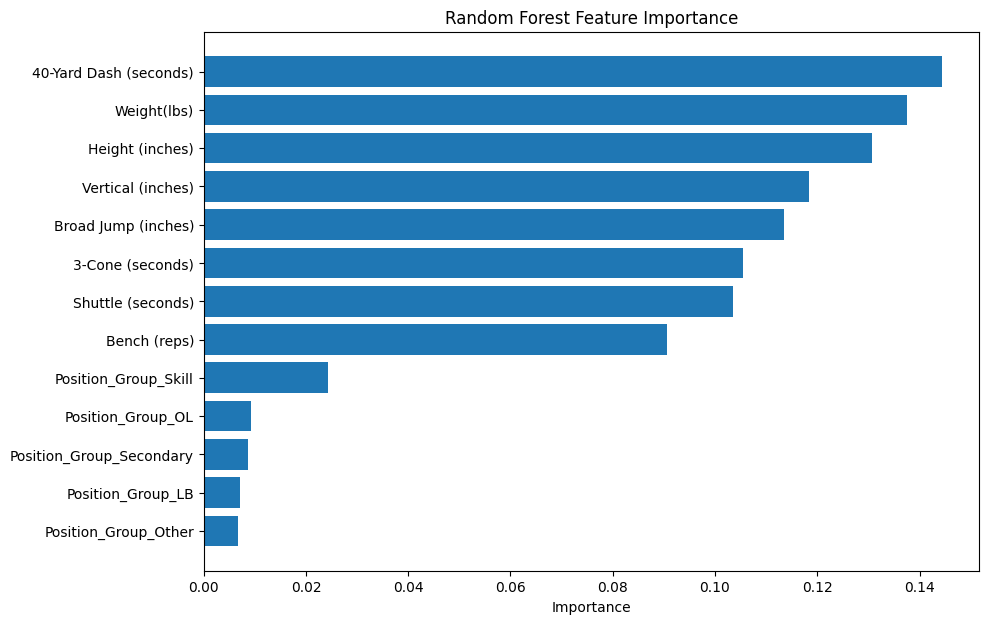

In [94]:
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(10,7))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()

In [95]:
train_pred = rf_model.predict(X_train)
test_pred = rf_model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.7816091954022989
Testing Accuracy: 0.321875


In [96]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
train_pred = rf_model.predict(X_train)
test_pred = rf_model.predict(X_test)

# Accuracy
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, test_pred))

Training Accuracy: 0.46290491118077326
Testing Accuracy: 0.2875

Classification Report:
              precision    recall  f1-score   support

      Round1       0.21      0.44      0.29        32
   Rounds2_3       0.17      0.13      0.15        63
   Rounds4_5       0.25      0.32      0.28        62
   Rounds6_7       0.21      0.17      0.19        52
   Undrafted       0.48      0.37      0.42       111

    accuracy                           0.29       320
   macro avg       0.27      0.29      0.26       320
weighted avg       0.30      0.29      0.29       320



In [97]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-Validation Scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

Cross-Validation Scores: [0.328125   0.28515625 0.29803922 0.23921569 0.20392157]
Average CV Accuracy: 0.27089154411764704
